In [1]:
import sys
import os

os.chdir(os.path.abspath('..'))
%load_ext autoreload
%autoreload 2

# Calculate the project root directory
project_root = os.path.abspath('/home/ando/fm-playground')
utils = os.path.join(project_root, 'geofm_src/util')
print(f"Adding {project_root} and {utils} to sys.path")

# Add to sys.path -> necessary for importing the src package
if project_root not in sys.path:
    sys.path.append(project_root)

if utils not in sys.path:
    sys.path.append(utils)

Adding /home/ando/fm-playground and /home/ando/fm-playground/geofm_src/util to sys.path


In [3]:
print(sys.path)

['/home/ando/.conda/envs/fm/lib/python310.zip', '/home/ando/.conda/envs/fm/lib/python3.10', '/home/ando/.conda/envs/fm/lib/python3.10/lib-dynload', '', '/home/ando/.conda/envs/fm/lib/python3.10/site-packages', '/home/ando/fm-playground/src', '/home/ando/fm-playground', '/home/ando/fm-playground/geofm_src/util']


## Create splits 

If using for the first time: will save the splits to the root/splits directory

In [10]:
from geofm_src.datasets.fmow_wrapper import FmowBenchmarkDataset

dataset = FmowBenchmarkDataset(root='/data/panopticon/datasets/', split='test', )
dataset.df.head()

INFO:root:output_dtype: float32
INFO:root:Dataset size: 53473, sensor counts: {'WORLDVIEW02': 30148, 'WORLDVIEW03_VNIR': 10418, 'GEOEYE01': 9517, 'QUICKBIRD02': 3390, 'fmow_rgb': 0}
INFO:root:Normalizing images


,id,ms_path,ms_img_width,ms_img_height,ms_sensor_platform_name,ms_gsd,ms_timestamp,ms_approximate_wavelengths,ms_raw_location,rgb_path,rgb_img_width,rgb_img_height,rgb_sensor_platform_name,rgb_gsd,rgb_timestamp,rgb_approximate_wavelengths,rgb_raw_location,rgb_is_corrupt
0,shipyard_9_4,fmow/test/0010050/0010050_4_ms.tif,2629,1523,WORLDVIEW02,1.898325,2013-03-01T10:23:54Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_4_rgb.tif,10530,6099,WORLDVIEW02,0.473415,2013-03-01T10:23:54Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67947114370058...,True
1,shipyard_9_7,fmow/test/0010050/0010050_7_ms.tif,3569,2068,WORLDVIEW03_VNIR,1.403747,2016-01-05T10:11:07Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_7_rgb.tif,14289,8278,WORLDVIEW03_VNIR,0.350780,2016-01-05T10:11:07Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946551397688...,True
2,shipyard_9_0,fmow/test/0010050/0010050_0_ms.tif,2027,1175,QUICKBIRD02,2.483492,2003-09-07T09:32:10Z,"[474, 544, 661, 833]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_0_rgb.tif,8105,4695,QUICKBIRD02,0.621158,2003-09-07T09:32:10Z,"[661, 545, 477]","POLYGON ((20.412503388699999 54.6794661259515,...",True
3,shipyard_9_1,fmow/test/0010050/0010050_1_ms.tif,1211,702,QUICKBIRD02,4.192915,2014-01-24T09:35:10Z,"[474, 544, 661, 833]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_1_rgb.tif,4848,2808,QUICKBIRD02,1.051369,2014-01-24T09:35:10Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946929392450...,True
4,shipyard_9_6,fmow/test/0010050/0010050_6_ms.tif,3928,2276,WORLDVIEW03_VNIR,1.275527,2015-08-12T09:58:56Z,"[424, 481, 546, 605, 661, 724, 832, 949]",POLYGON ((20.412503388699999 54.67946734289999...,fmow/test/0010050/0010050_6_rgb.tif,15728,9111,WORLDVIEW03_VNIR,0.318811,2015-08-12T09:58:56Z,"[661, 545, 477]",POLYGON ((20.412503388699999 54.67946740734876...,True


In [23]:
import random

i = random.randint(0, len(dataset))
sample, label = dataset[i]
sample['imgs'].shape, label

(torch.Size([8, 1135, 1153]), 25)

# Test full dataset pipeline

## WV2 / 3

In [4]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/fmow_8b.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

INFO:root:output_dtype: float32
INFO:root:Removed 303 problematic images for train split
INFO:root:Dataset size: 275535
INFO:root:Dataset size: 275535, sensor counts: {'WORLDVIEW02': 204264, 'WORLDVIEW03_VNIR': 71271, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32
INFO:root:Removed 49 problematic images for val split
INFO:root:Dataset size: 40220
INFO:root:Dataset size: 40220, sensor counts: {'WORLDVIEW02': 30046, 'WORLDVIEW03_VNIR': 10174, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32
INFO:root:Dataset size: 40566
INFO:root:Dataset size: 40566, sensor counts: {'WORLDVIEW02': 30148, 'WORLDVIEW03_VNIR': 10418, 'GEOEYE01': 0, 'QUICKBIRD02': 0, 'fmow_rgb': 0}
INFO:root:Normalizing images


In [6]:
print(train_ds.problematic_ids)

[]


In [7]:
from tqdm.notebook import tqdm

for i in tqdm(range(len(train_ds))):
    _, _ = train_ds[i]

print(train_ds.problematic_ids)

  0%|          | 0/275535 [00:00<?, ?it/s]

Mismatching channel size: 171,train : torch.Size([4, 2414, 2462]), fmow_wv23


RuntimeError: The size of tensor a (4) must match the size of tensor b (8) at non-singleton dimension 0

In [10]:
train_ds.problematic_ids

[171]

In [12]:
train_ds.df.ms_path.iloc[171]

'fmow/train/shipyard/shipyard_10/shipyard_10_7_ms.tif'

In [14]:
path = '/data/panopticon/datasets/fmow/train/shipyard/shipyard_10/shipyard_10_7_ms.tif'
import tifffile
img = tifffile.imread(path)
img.shape



(2414, 2462, 4)

In [11]:
train_ds[171]

Mismatching channel size: 171,train : torch.Size([4, 2414, 2462]), fmow_wv23


RuntimeError: The size of tensor a (4) must match the size of tensor b (8) at non-singleton dimension 0

torch.Size([8, 224, 224]) 22 62


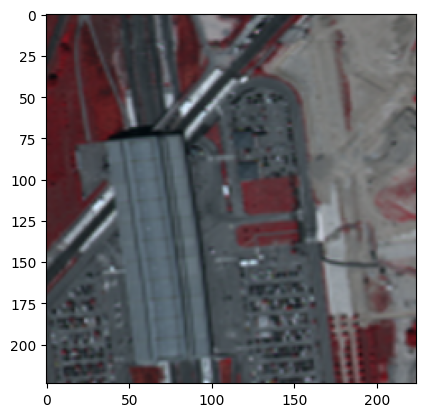

In [43]:
import random
import matplotlib.pyplot as plt
image, label = test_ds[random.randint(0, len(test_ds))]
print(image.shape, label, train_ds.num_classes)

image_rgb = image[[5,4,3], ...]
image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
image_rgb = image_rgb.permute(1, 2, 0)
plt.imshow(image_rgb)
plt.show()

# train_ds.plot(image)


In [44]:
from omegaconf import OmegaConf
from geofm_src.factory import create_dataset
# read in a config file from the configs/dataset folder
ds_cfg = OmegaConf.load('geofm_src/configs/dataset/fmow_4b.yaml')

train_ds, val_ds, test_ds = create_dataset(ds_cfg)

INFO:root:output_dtype: float32
INFO:root:Removed 303 problematic images
INFO:root:Dataset size: 87734, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 64544, 'QUICKBIRD02': 23190, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


Removed 303 problematic images


INFO:root:Removed 49 problematic images
INFO:root:Dataset size: 12771, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 9437, 'QUICKBIRD02': 3334, 'fmow_rgb': 0}
INFO:root:Normalizing images
INFO:root:output_dtype: float32


Removed 49 problematic images


INFO:root:Dataset size: 12907, sensor counts: {'WORLDVIEW02': 0, 'WORLDVIEW03_VNIR': 0, 'GEOEYE01': 9517, 'QUICKBIRD02': 3390, 'fmow_rgb': 0}
INFO:root:Normalizing images


torch.Size([4, 224, 224]) 61 62


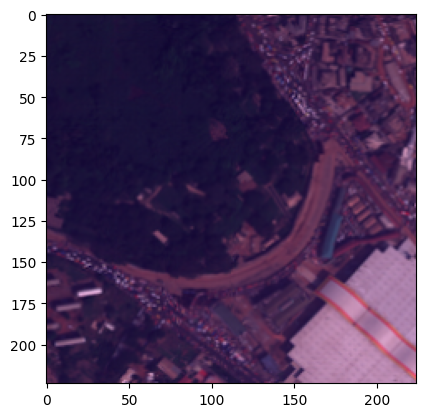

In [70]:
import random
import matplotlib.pyplot as plt
image, label = test_ds[random.randint(0, len(test_ds))]
print(image.shape, label, train_ds.num_classes)

image_rgb = image[[2,1,0], ...]
image_rgb = (image_rgb - image_rgb.min()) / (image_rgb.max() - image_rgb.min())
image_rgb = image_rgb.permute(1, 2, 0)
plt.imshow(image_rgb)
plt.show()

# train_ds.plot(image)
